In [42]:
import pandas as pd
import os
import sys
import warnings
import pickle
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.portfolio_selection_gurobi import optimize_markowitz_gurobi, PortfolioSelectionGurobi, get_returns_and_var
from src.performance_tracker import PerformanceTracker
from src.utils import get_combinations, add_noise, get_returns_df, find_weights_gurobi

In [2]:
grid = get_combinations()
data = get_returns_df()

# Validando solução gurobi

In [4]:
data = data[["B3SA3", "ITUB3"]]

In [33]:
sol = []
for w in range(0, 101, 5):
    w = w/100
    m = -( w*data.mean()[0] + (1-w)*data.mean()[1] )
    v = [w, 1-w] @ data.cov() @ [w, 1-w]
    sol.append( (m, v) )

In [34]:
import matplotlib.pyplot as plt 
sol_df = pd.DataFrame(sol)

{
    "ret_min": -0.0032222448057081117,
    "var_max": 0.0025934673359674304,
    "ret_max": -0.0017579570812722867,
    "var_min": 0.0014177552258810946,
    "min_ret_lim": 0.0022912698855869396,
    "max_var_lim": 0.0020056112809242626
}
`risk_0: [1. 0.]
risk_1:[0.21357295 0.78642705]


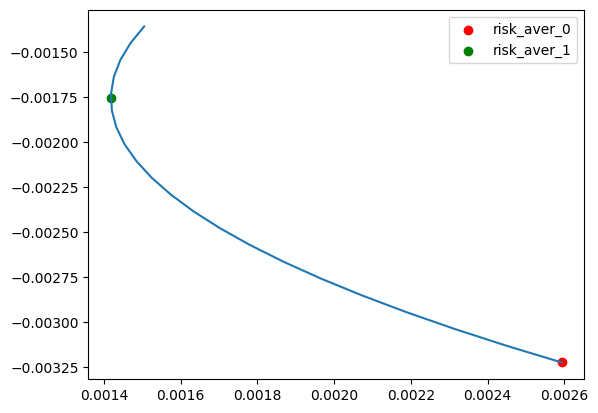

In [68]:
import numpy as np 
import json 
min_ret_percentile = 0.5
max_var_perc = 0.5
risk_aver = 0.5

num_ast = data.shape[1]
exp_ret_df = data.mean()
cov_mat = data.cov()

norm_prms = dict()
ga_no_risk_aver = PortfolioSelectionGurobi(data=data,
                                    num_ast=num_ast,
                                    exp_ret_df=exp_ret_df,
                                    cov_mat=cov_mat,
                                    risk_aver=0).optimize()
norm_prms["ret_min"], norm_prms["var_max"] = get_returns_and_var(exp_ret_df, cov_mat, ga_no_risk_aver)

ga_full_risk_aver = PortfolioSelectionGurobi(data=data,
                                            num_ast=num_ast,
                                            exp_ret_df=exp_ret_df,
                                            cov_mat=cov_mat,
                                            risk_aver=1).optimize()
norm_prms["ret_max"], norm_prms["var_min"] = get_returns_and_var(
    exp_ret_df, cov_mat, ga_full_risk_aver)

norm_prms["min_ret_lim"] = np.percentile(exp_ret_df,
                                            round(100 * min_ret_percentile))
norm_prms["max_var_lim"] = norm_prms["var_min"] + (norm_prms["var_max"] - norm_prms["var_min"]) * max_var_perc


best_individual = PortfolioSelectionGurobi(data=data,
                                        num_ast=num_ast,
                                        exp_ret_df=exp_ret_df,
                                        cov_mat=cov_mat,
                                        risk_aver=risk_aver,
                                        norm_param=norm_prms).optimize()

m, v = get_returns_and_var(exp_ret_df, cov_mat, best_individual)


print(json.dumps(norm_prms, indent=4))
print(f"`risk_0: {ga_no_risk_aver}\nrisk_1:{ga_full_risk_aver}")
plt.plot(sol_df[1], sol_df[0])
plt.scatter(norm_prms["var_max"], norm_prms["ret_min"], color = 'red', label="risk_aver_0")
plt.scatter(norm_prms["var_min"], norm_prms["ret_max"], color = 'green', label="risk_aver_1")
plt.legend()

In [48]:
data.mean() 

B3SA3    0.003222
ITUB3    0.001360
dtype: float64

In [ ]:
PortfolioSelectionGurobi


Restricted license - for non-production use only - expires 2025-11-24


# Base de Resultados

In [ ]:
dat_fim_tre = "2021-01-01"
data=data[:dat_fim_tre]
results = []
for parameters in tqdm(grid):
    df = find_weights_gurobi(data, parameters)
    results.append({
        "parameters": parameters,
        "df": df
    })

# extender resultados para steps 2, 3 e 4
ext_results = []
for res in results:
    for step in [2, 3, 4]:
        parameters = res["parameters"].copy()
        res_df = res["df"].copy()
        parameters["step"] = step
        res_df.reset_index(inplace=True, drop=True)
        res_df.loc[~res_df.index.isin(range(0, res_df.shape[0]+1, step)), "weights"] = None
        res_df.fillna(method='ffill', inplace=True)
        res_df["portfolio_return"] = res_df.apply(lambda x: x["weights"] @ data.loc[x["Date"]], axis=1)
        ext_results.append({
            "parameters": parameters.copy(),
            "df": res_df.copy()
        })
results.extend(ext_results)
# with open('../data/results.pkl', 'wb') as f:
#     pickle.dump(results, f)

# Avaliar resultados

In [3]:
# #load results
# with open('../data/results.pkl', 'rb') as f:
#     results = pickle.load(f)

In [3]:
#load results
with open('../data/results_parralel.pkl', 'rb') as f:
    results = pickle.load(f)

In [21]:
ext_results = []
for res in results:
    for step in [2, 3, 4]:
        parameters = res["parameters"].copy()
        res_df = res["df"].copy()
        parameters["step"] = step
        res_df.reset_index(inplace=True, drop=True)
        res_df.loc[~res_df.index.isin(range(0, res_df.shape[0]+1, step)), "weights"] = None
        res_df.fillna(method='ffill', inplace=True)
        res_df["portfolio_return"] = res_df.apply(lambda x: x["weights"] @ data.loc[x["Date"]], axis=1)
        ext_results.append({
            "parameters": parameters.copy(),
            "df": res_df.copy()
        })
results.extend(ext_results)
# with open('../data/results_parallel2.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [4]:
for result in results:
    result["df"].set_index("Date", inplace=True)

In [8]:
dat_ini_tre = "2019-05-19"
dat_fim_tre = "2020-11-19"

In [9]:
results_df = pd.DataFrame(results)

In [10]:
results_df.iloc[0]["df"][dat_ini_tre:dat_fim_tre]

,weights,portfolio_return
Date,,
2019-05-19,"[3.0476062622412205e-09, 2.463977528979304e-09...",-0.125087
2019-05-26,"[6.700994748368289e-10, 5.327345244443975e-10,...",0.027289
2019-06-02,"[5.722041896903514e-09, 4.4159472066675135e-09...",-0.029275
2019-06-09,"[3.1721738818696413e-09, 2.326224378546643e-09...",-0.043456
2019-06-16,"[2.637706310627912e-09, 2.142082464381942e-09,...",0.027169
...,...,...
2020-10-18,"[2.2060924056569192e-11, 2.1597674550912573e-1...",0.108456
2020-10-25,"[4.785946517301421e-10, 4.233595610434513e-10,...",0.034505
2020-11-01,"[8.330097809056917e-10, 8.696136626683974e-10,...",-0.015030


In [11]:
results_df["performance_tracker"] = results_df.apply( lambda x:
    PerformanceTracker(
        data=x["df"][dat_ini_tre:dat_fim_tre]["portfolio_return"],
        mkt_ret=data[dat_ini_tre:dat_fim_tre].mean(axis=1),
        risk_free=0.06,
        period="weekly"
    )(), 
    axis=1
)
results_df[list(results_df["performance_tracker"].iloc[0].keys())]= results_df['performance_tracker'].apply(pd.Series)
results_df["rank"] = results_df["alpha"].rank(ascending=False) + results_df["expected_loss_weekly_95"].rank(ascending=False) + results_df["max_drawdown"].rank(ascending=False) + results_df["sharpe_ratio"].rank(ascending=False)

In [12]:
parameters=results_df.sort_values(by="rank").iloc[0]["parameters"]

In [ ]:
results_df.sort_values(by="rank")

In [ ]:
import matplotlib.pyplot as plt 

for i in range(50):
    
    (1+results_df.sort_values(by="rank").iloc[-i]["df"]).cumprod().plot()
    plt.title(results_df.sort_values(by="rank").iloc[-i]["parameters"])

In [ ]:
(1+data[dat_ini_tre:dat_fim_tre].mean(axis=1)).cumprod().plot()

In [ ]:
parameters

In [34]:
# parameters = {'risk_aver': 0.75,
#  'min_ret_percentile': 0.25,
#  'max_var_perc': 0.25,
#  'window': 24,
#  'step': 3}

In [13]:
dat_ini_tst_24 = "2020-06-07"
dat_ini_tst = "2020-11-19"
dat_fim_tst = "2023-04-09"

In [14]:
data_tst = data[dat_ini_tst_24:dat_fim_tst]

In [15]:
df = find_weights_gurobi(data_tst, parameters)

Restricted license - for non-production use only - expires 2025-11-24


In [21]:
df

,Date,weights,portfolio_return
0,2021-06-06,"[9.367167094937416e-11, 1.0277410408655689e-10...",0.098598
1,2021-06-13,"[3.1856260764310976e-10, 3.6445498568810146e-1...",-0.038577
2,2021-06-20,"[4.587166080752581e-10, 6.31489277498662e-10, ...",-0.091451
3,2021-06-27,"[8.721640924247896e-10, 1.0056613371436144e-09...",0.008633
4,2021-07-04,"[3.2303381847029838e-09, 3.3644581360544355e-0...",0.006695
...,...,...,...
92,2023-03-12,"[2.199927373722338e-09, 1.4145720278953516e-09...",-0.012428
93,2023-03-19,"[5.572803021776469e-10, 5.68640402313493e-10, ...",-0.028167
94,2023-03-26,"[1.1372528188127772e-09, 3.2174489919365995e-0...",-0.001185
95,2023-04-02,"[1.8988381343456663e-09, 5.714633150273413e-09...",-0.003726


<Axes: >

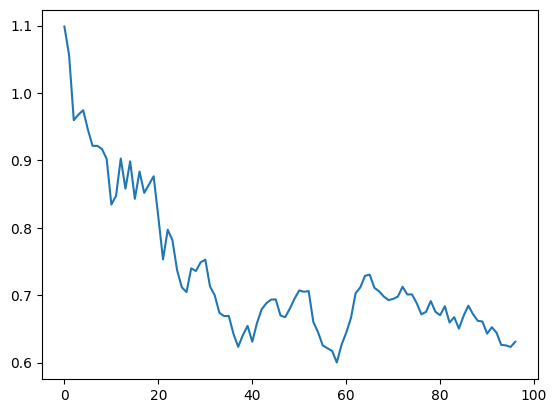

In [18]:
(1+df["portfolio_return"]).cumprod().plot()

In [16]:
PerformanceTracker(
        data=df["portfolio_return"],
        mkt_ret=data[dat_ini_tst:dat_fim_tst].mean(axis=1),
        risk_free=0.06,
        period="weekly"
)()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 97 and the array at index 1 has size 125

In [ ]:
PerformanceTracker(
        data=data[dat_ini_tst:dat_fim_tst].mean(axis=1),
        mkt_ret=data[dat_ini_tst:dat_fim_tst].mean(axis=1),
        risk_free=0.06,
        period="weekly"
)()

In [ ]:
(1+df["portfolio_return"]).cumprod().plot()

In [ ]:
(1+data[dat_ini_tst:dat_fim_tst].mean(axis=1)).cumprod().plot()

In [ ]:
results_df.df.iloc[0]

In [ ]:
import json
import matplotlib.pyplot as plt 
for i,r in results_df.iterrows():
    (1+r["df"].portfolio_return).cumprod().plot(label=json.dumps(r["parameters"]))
    # plt.legend()